## PROYECTO FINAL - Clasificación de pacientes con esquizofrenia

Alumnos: Ricardo Amiel y Josué Jeremias

## Estado del pipeline
*(este bloque se actualiza en cada iteración para saber siempre en qué fase estamos)*

**Fase 1 — Preprocesamiento EEG — COMPLETADA Y CONFIRMADA**
- [x] Carga de metadatos y mapeo binario de diagnóstico (sano=0 / esquizofrenia=1)
- [x] Función de preprocesamiento por archivo (filtros 0.5–45 Hz, notch 50 Hz, resample 250 Hz, ventanas 5 s, z-score)
- [x] Armonización de canales por nombre — confirmado: 153/153 sujetos recuperados (77 control / 76 paciente), ventanas balanceadas (2946 vs 3000)
- [x] Split train/val/test a nivel de sujeto — confirmado: 107/23/23 sujetos, balance de clases razonable en cada conjunto (0.53 / 0.44 / 0.44)

**Fase 2 — Transformación a imágenes tiempo-frecuencia — código agregado, pendiente de ejecutar**
- [x] Espectrogramas STFT (función probada, corre correctamente sobre todo X)
- [~] Escalogramas Wavelet: descartados por decisión (cuello de botella de rendimiento); se prioriza FFT/STFT
- [ ] Aplicar split a `X_stft` + normalización log1p/z-score (código listo, falta correr y confirmar)

**Fase 3 — Extracción y selección de características clásicas — código agregado, pendiente de ejecutar**
- [ ] Extracción de características con `tsfresh` (canal por canal, `MinimalFCParameters`)
- [ ] Imputación y selección de características (ajustada solo con train)

**Fase 4 — Entrenamiento de modelos — código agregado, pendiente de ejecutar**
- [ ] Modelos clásicos: SVM, XGBoost, Random Forest, Regresión logística
- [ ] Modelos DL: CNN propia + ResNet18 (transfer learning, conv1 adaptada a 19 canales)
- [ ] (Omitido por alcance) ViT/Swin o EEG-Conformer

**Fase 5 — Comparación experimental final — código agregado, pendiente de ejecutar**
- [ ] Evaluación final en TEST de los 6 modelos
- [ ] Tabla comparativa clásico vs. deep learning
- [ ] Matrices de confusión
- [ ] Conclusiones (plantilla agregada, pendiente de redactar con resultados reales)

Leyenda: `[x]` completado y confirmado · `[~]` completado pero descartado/cambiado de plan · `[ ]` pendiente

In [112]:
import os
import glob
import re
import numpy as np
import pandas as pd
import mne
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =====================================================================
# 1. PARÁMETROS GENERALES DE PREPROCESAMIENTO CLÍNICO
# =====================================================================
BASE_DATASET_DIR = "./ASZED-153"
CSV_PATH = os.path.join(BASE_DATASET_DIR, "ASZED_SpreadSheet.csv")

FREQ_LOW = 0.5       # Filtro pasa-alta (remueve deriva lenta de los electrodos)
FREQ_HIGH = 45.0     # Filtro pasa-baja (remueve interferencia electromuscular de alta frecuencia)
FREQ_NOTCH = 50.0    # Filtro Notch (remueve el ruido de la línea eléctrica ambiental)
WINDOW_SEC = 5.0     # Tamaño de cada ventana temporal de EEG en segundos
TARGET_SFREQ = 250.0

# [FIX] El dataset ASZED tiene DOS formatos de adquisición distintos:
#   Formato A: 'EEG Fp1-LE', 'EEG C3-LE', ... (20 canales, incluye referencia A2, 256 Hz)
#   Formato B: 'Fp1[1]', 'C3[5]', ... (24 canales, incluye EMG/EOG/Pg1/Pg2, 200-100 Hz)
# Ambos comparten el mismo set de 19 electrodos estándar 10-20. Armonizamos por NOMBRE
# (no por conteo de canales) para no perder ningún sujeto de ninguna clase.
CANONICAL_CHANNELS = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
                       'T3', 'C3', 'Cz', 'C4', 'T4',
                       'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

def normalize_channel_name(name):
    """Normaliza nombres de canal de ambos formatos de adquisición a la
    convención estándar 10-20: quita prefijo 'EEG ', sufijo '-LE' y
    sufijo numérico '[n]'."""
    n = name.strip()
    n = re.sub(r'^EEG\s+', '', n, flags=re.IGNORECASE)
    n = re.sub(r'-LE$', '', n, flags=re.IGNORECASE)
    n = re.sub(r'\[\d+\]$', '', n)
    return n

print("Librerías cargadas. Configurando pipeline...")


Librerías cargadas. Configurando pipeline...


## Preprocesamiento EEG


### Fase 1. Carga y organización de los registros por sujeto, clase y paradigma experimental.

In [113]:
# =====================================================================
# 2. CARGA Y TRADUCCIÓN BINARIA DE METADATOS
# =====================================================================
mapping_dict = {}

try:
    df_meta = pd.read_csv(CSV_PATH)
    df_meta.columns = df_meta.columns.str.strip()
    df_meta['sn_clean'] = df_meta['sn'].astype(str).str.strip().str.lower()
    df_meta['category_clean'] = df_meta['category'].astype(str).str.strip().str.lower()
    
    # Mapeo binario: 'patient' -> 1 (Esquizofrenia), 'control' -> 0 (Sano)
    df_meta['Diagnosis'] = df_meta['category_clean'].apply(lambda x: 1 if 'patient' in x else 0)
    mapping_dict = dict(zip(df_meta['sn_clean'], df_meta['Diagnosis']))
    
    print(f"[✓] SpreadSheet mapeada con éxito.")
    print(f"    -> Total de sujetos registrados en el CSV maestro: {len(mapping_dict)}")
except Exception as e:
    print(f"[!] Error crítico procesando el archivo CSV: {e}")

[✓] SpreadSheet mapeada con éxito.
    -> Total de sujetos registrados en el CSV maestro: 153


In [114]:
df_meta

,sn,age,gender,category,language,node,sn_clean,category_clean,Diagnosis
0,subject_2,50,F,Patient,Yoruba,OAUTHC_IFE_ILESA,subject_2,patient,1
1,subject_3,45,F,Patient,English,OAUTHC_IFE_ILESA,subject_3,patient,1
2,subject_4,35,M,Patient,English,OAUTHC_IFE_ILESA,subject_4,patient,1
3,subject_5,28,M,Patient,English,OAUTHC_IFE_ILESA,subject_5,patient,1
4,subject_6,39,F,Patient,English,OAUTHC_IFE_ILESA,subject_6,patient,1
...,...,...,...,...,...,...,...,...,...
148,subject_156,44,M,Control,English,OAUTHC_IFE_ILESA,subject_156,control,0
149,subject_157,30,F,Control,English,OAUTHC_IFE_ILESA,subject_157,control,0
150,subject_158,51,M,Control,Yoruba,OAUTHC_IFE_ILESA,subject_158,control,0
151,subject_159,33,F,Control,English,OAUTHC_IFE_ILESA,subject_159,control,0


In [115]:
# =====================================================================
# 3. FUNCIÓN DE PREPROCESAMIENTO CLÍNICO POR ARCHIVO (con armonización de canales)
# =====================================================================
def preprocess_edf_file(edf_path, freq_low, freq_high, freq_notch, window_sec, target_sfreq=250.0):
    """
    Carga señales .edf, ARMONIZA los canales al estándar 10-20 de 19 canales
    (sin importar el formato de adquisición original), remuestrea a frecuencia
    estándar, filtra ruidos y segmenta aplicando normalización Z-score.

    Retorna (windows, sfreq, reason). 'reason' es None si todo salió bien,
    o un string explicando por qué se descartó el archivo.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        # [FIX] Armonización de nombres de canal entre los dos formatos del dataset
        rename_map = {}
        for ch in raw.ch_names:
            norm = normalize_channel_name(ch)
            for canon in CANONICAL_CHANNELS:
                if norm.lower() == canon.lower():
                    rename_map[ch] = canon
                    break
        raw.rename_channels(rename_map)

        available = [c for c in CANONICAL_CHANNELS if c in raw.ch_names]
        if len(available) < len(CANONICAL_CHANNELS):
            missing = sorted(set(CANONICAL_CHANNELS) - set(available))
            return None, None, f"faltan canales: {missing}"

        # Selecciona EXACTAMENTE los 19 canales estándar, siempre en el mismo orden
        # (descarta de paso EMG/EOG/Pg1/Pg2/A2, que no son señal cortical comparable)
        raw.pick_channels(CANONICAL_CHANNELS, ordered=True)

        if raw.info['sfreq'] != target_sfreq:
            raw.resample(sfreq=target_sfreq, verbose=False)

        raw.filter(l_freq=freq_low, h_freq=freq_high, fir_design='firwin', verbose=False)
        raw.notch_filter(freqs=freq_notch, fir_design='firwin', verbose=False)

        data, times = raw.get_data(return_times=True)
        sfreq = raw.info['sfreq']

        samples_per_window = int(window_sec * sfreq)
        total_samples = data.shape[1]
        num_windows = total_samples // samples_per_window

        if num_windows == 0:
            return None, None, f"registro muy corto ({total_samples} muestras)"

        file_windows = []
        for w in range(num_windows):
            start_idx = w * samples_per_window
            end_idx = start_idx + samples_per_window
            window_data = data[:, start_idx:end_idx]

            # Normalización Z-score por canal
            mean = np.mean(window_data, axis=1, keepdims=True)
            std = np.std(window_data, axis=1, keepdims=True) + 1e-8
            normalized_window = (window_data - mean) / std

            file_windows.append(normalized_window)

        return np.array(file_windows), sfreq, None
    except Exception as e:
        return None, None, f"excepción: {e}"


In [116]:
# =====================================================================
# 4. EXTRACCIÓN Y PROCESAMIENTO RECURSIVO (con canales ya armonizados)
# =====================================================================
from collections import Counter

all_windows = []
all_labels = []
all_subjects = []

# Escaneo dinámico recursivo agnóstico a las carpetas intermedias
subject_folders = glob.glob(os.path.join(BASE_DATASET_DIR, "**", "subject_*"), recursive=True) + \
                  glob.glob(os.path.join(BASE_DATASET_DIR, "**", "Subject_*"), recursive=True)
subject_folders = sorted(list(set(subject_folders)))

print("\n[*] Iniciando carga masiva y procesamiento digital de señales...")

discard_reasons = Counter()
processed_files = 0
expected_shape = (len(CANONICAL_CHANNELS), int(WINDOW_SEC * TARGET_SFREQ))

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)

    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    try:
        sub_id_int = int(folder_name.split("_")[-1])
    except ValueError:
        sub_id_int = 999

    for edf_path in edf_files:
        processed_files += 1
        windows, sfreq, reason = preprocess_edf_file(edf_path, FREQ_LOW, FREQ_HIGH, FREQ_NOTCH, WINDOW_SEC, TARGET_SFREQ)

        if windows is None:
            discard_reasons[reason] += 1
            continue

        for window in windows:
            # Verificación defensiva: con la armonización de canales esto SIEMPRE debe cumplirse
            assert window.shape == expected_shape, f"Forma inesperada {window.shape} en {edf_path}"
            all_windows.append(window)
            all_labels.append(label)
            all_subjects.append(sub_id_int)

print(f"[INFO] Archivos .edf procesados: {processed_files}")
if discard_reasons:
    print("[INFO] Archivos descartados por motivo:")
    for reason, count in discard_reasons.most_common():
        print(f"   - {reason}: {count}")
else:
    print("[INFO] Ningún archivo descartado.")



[*] Iniciando carga masiva y procesamiento digital de señales...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code s

In [117]:
# =====================================================================
# 5. CONSOLIDACIÓN DE MATRICES TRIDIMENSIONALES DE ENTRADA
# =====================================================================
print("\n" + "=" * 60)
print("             FASE 1 COMPLETADA: RESUMEN DE MATRICES             ")
print("=" * 60)

if len(all_windows) > 0:
    X = np.array(all_windows)
    y = np.array(all_labels)
    groups = np.array(all_subjects)

    print(f"[✓] Matriz X consolidada (Ventanas, Canales, Muestras): {X.shape}")
    print(f"[✓] Vector y consolidado (Etiquetas Binarias):           {y.shape}")
    print(f"    - Ventanas Totales de Controles Sanos (Clase 0): {np.sum(y == 0)}")
    print(f"    - Ventanas Totales de Pacientes (Clase 1):      {np.sum(y == 1)}")
    print(f"    - Total de sujetos únicos integrados al pipeline: {len(np.unique(groups))}")

    # [FIX] Verificación clave: ¿sobreviven sujetos de ambas clases en proporción razonable?
    df_check = pd.DataFrame({'subject': groups, 'label': y})
    print(f"    - Sujetos únicos por clase (0=control, 1=paciente):")
    print(df_check.groupby('label')['subject'].nunique().to_string())
else:
    print("[!] Error crítico en el pipeline: No se pudo consolidar ninguna ventana numérica.")


             FASE 1 COMPLETADA: RESUMEN DE MATRICES             


[✓] Matriz X consolidada (Ventanas, Canales, Muestras): (5946, 19, 1250)
[✓] Vector y consolidado (Etiquetas Binarias):           (5946,)
    - Ventanas Totales de Controles Sanos (Clase 0): 2946
    - Ventanas Totales de Pacientes (Clase 1):      3000
    - Total de sujetos únicos integrados al pipeline: 153
    - Sujetos únicos por clase (0=control, 1=paciente):
label
0    77
1    76


### Diagnóstico previo: ¿por qué se descartan tantas ventanas/sujetos?

Antes de seguir con el pipeline, inspeccionamos los `.edf` **sin cargar las señales completas** (solo headers) para entender si el descarte masivo del Shape Guard (3102 ventanas descartadas) se debe a una diferencia real de canales entre sujetos, y si esto está afectando desproporcionadamente a una de las dos clases.

In [118]:
# =====================================================================
# DIAGNÓSTICO: inspección de headers .edf (sin preload) por sujeto
# =====================================================================
diag_rows = []

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)
    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    if len(edf_files) == 0:
        diag_rows.append({
            "subject": folder_name, "label": label, "file": None,
            "n_channels": None, "channel_names": None, "sfreq": None,
            "duration_sec": None, "error": "sin .edf encontrado"
        })
        continue

    for edf_path in edf_files:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            raw.pick_types(eeg=True, stim=False, exclude='bads', verbose=False)
            diag_rows.append({
                "subject": folder_name,
                "label": label,
                "file": os.path.basename(edf_path),
                "n_channels": len(raw.ch_names),
                "channel_names": tuple(sorted(raw.ch_names)),
                "sfreq": raw.info['sfreq'],
                "duration_sec": raw.n_times / raw.info['sfreq'],
                "error": None
            })
        except Exception as e:
            diag_rows.append({
                "subject": folder_name, "label": label, "file": os.path.basename(edf_path),
                "n_channels": None, "channel_names": None, "sfreq": None,
                "duration_sec": None, "error": str(e)
            })

df_diag = pd.DataFrame(diag_rows)
print(f"Total de archivos .edf inspeccionados: {len(df_diag)}")
print(f"Archivos con error de lectura: {df_diag['error'].notna().sum()}")

Total de archivos .edf inspeccionados: 1932
Archivos con error de lectura: 0


In [119]:
# =====================================================================
# DIAGNÓSTICO: distribución de canales / sfreq y supervivencia por clase
# =====================================================================
print("Distribución de número de canales EEG por archivo:")
print(df_diag['n_channels'].value_counts(dropna=False))
print()

print("Distribución de frecuencias de muestreo (sfreq):")
print(df_diag['sfreq'].value_counts(dropna=False))
print()

print("Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):")
print(df_meta.groupby('Diagnosis')['sn_clean'].nunique())
print()

df_diag_ok = df_diag.dropna(subset=['n_channels'])
print("Sujetos únicos con al menos un .edf leíble, por clase:")
print(df_diag_ok.groupby('label')['subject'].nunique())
print()

most_common_n_channels = df_diag_ok['n_channels'].mode()[0]
print(f"Número de canales más frecuente (el que quedó como 'molde' = {most_common_n_channels}):")
matching = df_diag_ok[df_diag_ok['n_channels'] == most_common_n_channels]
not_matching = df_diag_ok[df_diag_ok['n_channels'] != most_common_n_channels]
print(f"  Archivos que SÍ calzan: {len(matching)}  -> sujetos únicos: {matching['subject'].nunique()}")
print(f"  Archivos que NO calzan: {len(not_matching)}  -> sujetos únicos: {not_matching['subject'].nunique()}")
print()

print("Sujetos únicos que SÍ calzan con el molde, por clase:")
print(matching.groupby('label')['subject'].nunique())
print()
print("Sujetos únicos que NO calzan con el molde, por clase:")
print(not_matching.groupby('label')['subject'].nunique())
print()

unique_channel_sets = df_diag_ok['channel_names'].value_counts()
print(f"Número de combinaciones distintas de NOMBRES de canal encontradas: {len(unique_channel_sets)}")
print(unique_channel_sets.head(10))

Distribución de número de canales EEG por archivo:
n_channels
20    1149
24     783
Name: count, dtype: int64

Distribución de frecuencias de muestreo (sfreq):
sfreq
256.0    1149
200.0     759
100.0      24
Name: count, dtype: int64

Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):
Diagnosis
0    77
1    76
Name: sn_clean, dtype: int64

Sujetos únicos con al menos un .edf leíble, por clase:
label
0    77
1    76
Name: subject, dtype: int64

Número de canales más frecuente (el que quedó como 'molde' = 20):
  Archivos que SÍ calzan: 1149  -> sujetos únicos: 77
  Archivos que NO calzan: 783  -> sujetos únicos: 76

Sujetos únicos que SÍ calzan con el molde, por clase:
label
0    53
1    24
Name: subject, dtype: int64

Sujetos únicos que NO calzan con el molde, por clase:
label
0    24
1    52
Name: subject, dtype: int64

Número de combinaciones distintas de NOMBRES de canal encontradas: 2
channel_names
(EEG A2-LE, EEG C3-LE, EEG C4-LE, EEG Cz-LE, EEG F3-LE, EEG F4-LE, 

### Fase 1 (cierre). Split train / val / test a nivel de sujeto

Dividimos primero la lista de **sujetos** (no de ventanas) en train/val/test, estratificando por etiqueta de diagnóstico para mantener el balance de clases en cada conjunto, y luego propagamos esa asignación a las ventanas. Así garantizamos que todas las ventanas de un mismo sujeto queden en un único conjunto, como exige el proyecto.

In [120]:
# =====================================================================
# 6. SPLIT TRAIN / VAL / TEST A NIVEL DE SUJETO (sin fuga de información)
# =====================================================================
# El proyecto exige que TODAS las ventanas de un mismo sujeto queden en un
# único conjunto. Por eso NO usamos train_test_split directamente sobre las
# ventanas (eso mezclaría sujetos entre train/val/test), sino que dividimos
# primero la tabla de sujetos, estratificando por su etiqueta de diagnóstico
# para conservar el balance de clases, y luego propagamos esa asignación
# a nivel de ventana mediante máscaras booleanas.
from sklearn.model_selection import train_test_split

# 1. Tabla de un renglón por sujeto (cada sujeto tiene una sola etiqueta)
subject_df = pd.DataFrame({'subject': groups, 'label': y}).drop_duplicates()
assert subject_df['subject'].is_unique, "Un mismo sujeto no debería tener etiquetas distintas"

# 2. Proporciones del split (a nivel sujeto): 70% train / 15% val / 15% test
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
RANDOM_STATE = 42

train_subj, temp_subj = train_test_split(
    subject_df, test_size=(VAL_FRAC + TEST_FRAC),
    stratify=subject_df['label'], random_state=RANDOM_STATE
)
val_subj, test_subj = train_test_split(
    temp_subj, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_subj['label'], random_state=RANDOM_STATE
)

train_ids = set(train_subj['subject'])
val_ids = set(val_subj['subject'])
test_ids = set(test_subj['subject'])

# 3. Máscaras a nivel de ventana, propagando la asignación del sujeto
train_mask = np.isin(groups, list(train_ids))
val_mask = np.isin(groups, list(val_ids))
test_mask = np.isin(groups, list(test_ids))

# Verificación defensiva: cada ventana debe caer en exactamente un conjunto
assert (train_mask.astype(int) + val_mask.astype(int) + test_mask.astype(int) == 1).all()

print("[✓] Split a nivel de sujeto completado.")
print(f"    Sujetos -> train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")
print(f"    Ventanas -> train: {train_mask.sum()} | val: {val_mask.sum()} | test: {test_mask.sum()}")
print()
print("    Balance de clases por conjunto (proporción de clase 1 = paciente):")
for name, mask in [('train', train_mask), ('val', val_mask), ('test', test_mask)]:
    print(f"      {name}: {y[mask].mean():.3f}  (n={mask.sum()})")

[✓] Split a nivel de sujeto completado.
    Sujetos -> train: 107 | val: 23 | test: 23
    Ventanas -> train: 4333 | val: 749 | test: 864

    Balance de clases por conjunto (proporción de clase 1 = paciente):
      train: 0.529  (n=4333)
      val: 0.439  (n=749)
      test: 0.436  (n=864)


In [121]:
# =====================================================================
# 7. APLICACIÓN DEL SPLIT A LOS TENSORES DE DATOS
# =====================================================================
# A partir de aquí trabajamos con conjuntos ya separados. Cualquier paso que
# 'aprenda' de los datos (selección de características, normalización con
# estadísticos globales, entrenamiento de modelos) debe ajustarse SOLO con
# los conjuntos *_train, y aplicarse después a *_val / *_test — nunca al revés.
X_train, y_train, groups_train = X[train_mask], y[train_mask], groups[train_mask]
X_val,   y_val,   groups_val   = X[val_mask],   y[val_mask],   groups[val_mask]
X_test,  y_test,  groups_test  = X[test_mask],  y[test_mask],  groups[test_mask]

print(f"[✓] X dividido -> train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

# NOTA: X_stft se generará en la Fase 2 directamente desde X_train_filtered, X_val_filtered, X_test_filtered
# (no desde X_train, X_val, X_test) después del filtrado de canales. Por eso no lo dividimos aquí con máscaras.

[✓] X dividido -> train: (4333, 19, 1250) | val: (749, 19, 1250) | test: (864, 19, 1250)


Note que, si intentamos obtener los datos sin una **frecuencia con cota superior** da error debido a que muchas señales se muestrean en distintas frecuencias. 

Algunos registros .edf pueden venir muestreados a 250 Hz, otros a 500 Hz o 1000 Hz. Al multiplicar duración×sfreq, un archivo genera ventanas de 1250 puntos de tiempo y otro genera 2500 o 5000 puntos.

Algunos archivos incluyen electrodos adicionales de referencia, canales de electrocardiograma (ECG), electrooculograma (EOG) o canales de anotación de eventos de la máquina, haciendo que un sujeto tenga 19 canales y otro tenga 20 o 22.

Al meter este bloque, las dimensiones de X se volverán homogéneas. Cuéntame qué forma (shape) te arroja la impresión final del reporte para saber con certeza que tus tensores están listos, aunque para ello tenemos que descartar ventanas con comportamientos anómalos.

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import ttest_ind

# Definimos los 19 canales extraídos en tu Fase 1
CANONICAL_CHANNELS = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

def ranking_canales_por_psd(X, y, channels, sfreq=250, n_top=10):
    """
    Calcula la potencia espectral promedio por canal usando Welch,
    aplica una prueba t de Student entre sanos y esquizofrenia,
    y ordena los canales de menor a mayor p-value (más discriminantes).
    """
    n_ventanas, n_canales, n_samples = X.shape
    p_values = []
    
    # Separamos ventanas por clase
    clase_sanos = X[y == 0]
    clase_esquizo = X[y == 1]
    
    print("-> Analizando la contribución de ruido vs señal por canal...")
    for ch in range(n_canales):
        # Densidad de Potencia Espectral (PSD)
        _, psd_sanos = welch(clase_sanos[:, ch, :], fs=sfreq, nperseg=256)
        _, psd_esquizo = welch(clase_esquizo[:, ch, :], fs=sfreq, nperseg=256)
        
        # Potencia promedio por ventana para este canal
        power_sanos = np.mean(psd_sanos, axis=1)
        power_esquizo = np.mean(psd_esquizo, axis=1)
        
        # Test estadístico para evaluar si el canal diferencia ambas poblaciones
        _, p_val = ttest_ind(power_sanos, power_esquizo, equal_var=False)
        p_values.append(p_val)

        if p_val < 0.05:
            print(f"    [!] Canal {channels[ch]}: p-value = {p_val:.4e} (significativo)")
        else:
            print(f"    [ ] Canal {channels[ch]}: p-value = {p_val:.4e} (no significativo)")
            
        
    df_ranking = pd.DataFrame({
        'Canal': channels,
        'p-value': p_values
    }).sort_values('p-value')
    
    print("\n=== RANKING DE RELEVANCIA DE CANALES (Menor p-value = Mayor Alteración) ===")
    print(df_ranking.to_string(index=False))
    
    top_canales = df_ranking.head(n_top)['Canal'].tolist()
    indices_top = [channels.index(ch) for ch in top_canales]
    
    return indices_top, top_canales

# Suponiendo que tus tensores de la Fase 1 se llaman X_train, y_train, X_val, X_test
# Ajustamos la selección usando ÚNICAMENTE el conjunto de entrenamiento para evitar fuga
indices_optimos, nombres_optimos = ranking_canales_por_psd(X_train, y_train, CANONICAL_CHANNELS, sfreq=250, n_top=18)

# Aplicamos el filtro para eliminar canales ruidosos o redundantes
X_filtered = X[:, indices_optimos, :]
X_train_filtered = X_train[:, indices_optimos, :]
X_val_filtered = X_val[:, indices_optimos, :]
X_test_filtered = X_test[:, indices_optimos, :]

print(f"\n[OK] Tensores filtrados con éxito.")
print(f"Forma original de X_train: {X_train.shape}")
print(f"Nueva forma limpia de X_train: {X_train_filtered.shape}")

-> Analizando la contribución de ruido vs señal por canal...
    [!] Canal Fp1: p-value = 9.7847e-29 (significativo)
    [!] Canal Fp2: p-value = 5.7445e-58 (significativo)
    [!] Canal F7: p-value = 7.9097e-37 (significativo)
    [!] Canal F3: p-value = 4.4023e-59 (significativo)
    [!] Canal Fz: p-value = 4.6724e-32 (significativo)
    [!] Canal F4: p-value = 2.7775e-49 (significativo)
    [!] Canal F8: p-value = 1.8198e-46 (significativo)
    [!] Canal T3: p-value = 1.1827e-40 (significativo)
    [!] Canal C3: p-value = 1.3224e-39 (significativo)
    [ ] Canal Cz: p-value = 7.2150e-01 (no significativo)
    [!] Canal C4: p-value = 1.1447e-29 (significativo)
    [!] Canal T4: p-value = 4.2290e-57 (significativo)
    [!] Canal T5: p-value = 9.8187e-13 (significativo)
    [!] Canal P3: p-value = 4.3129e-39 (significativo)
    [!] Canal Pz: p-value = 1.8009e-46 (significativo)
    [!] Canal P4: p-value = 3.6884e-55 (significativo)
    [!] Canal T6: p-value = 6.4196e-57 (significativo)

Que Cz tenga un p-valor=0.7 significa que la actividad eléctrica en el centro geométrico de la cabeza es idéntica en sanos y enfermos; no aporta información. En cambio, Fz (región frontal) muestra picos e inestabilidad extrema en pacientes con esquizofrenia. Clínicamente, esto se conoce como hiperfrontalidad y desorganización de los ritmos corticales, una firma clásica de la enfermedad.

Obtener los top 6 canales

In [180]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Asumo que tus variables de la Fase 1 se llaman X_train_windows, y_train_windows
# y que tienes una lista CHANNELS_18 con los nombres de los canales.

def obtener_top_canales(X_train, y_train, channel_names, n_top=6):
    """
    Calcula la varianza promedio por ventana para cada canal y aplica un t-test
    para seleccionar los n_top canales que mejor discriminan entre clases.
    """
    n_canales = X_train.shape[1]
    p_values = []
    
    # Separar ventanas de entrenamiento por clase
    X_0 = X_train[y_train == 0]
    X_1 = X_train[y_train == 1]
    
    print(f"Evaluando relevancia de {n_canales} canales...")
    for ch in range(n_canales):
        # Usamos la varianza de la señal como métrica rápida de actividad
        var_0 = np.var(X_0[:, ch, :], axis=1)
        var_1 = np.var(X_1[:, ch, :], axis=1)
        
        # Test t de Student
        _, p_val = ttest_ind(var_0, var_1, equal_var=False)
        p_values.append(p_val)
        
    # Crear DataFrame de resultados
    df_ranking = pd.DataFrame({
        'Canal': channel_names,
        'p-value': p_values
    }).sort_values(by='p-value')
    
    top_canales_nombres = df_ranking.head(n_top)['Canal'].tolist()
    indices_top = [channel_names.index(ch) for ch in top_canales_nombres]
    
    print(f"\nTop {n_top} canales seleccionados: {top_canales_nombres}")
    return indices_top, top_canales_nombres

# 1. Obtener los índices de los 6 mejores canales SOLO con datos de entrenamiento
indices_top6, nombres_top6 = obtener_top_canales(X_train, y_train, CANONICAL_CHANNELS, n_top=6)

# 2. Filtrar los tensores para quedarse solo con esos 6 canales
X_top6 = X[:, indices_top6, :]
X_train_top6 = X_train[:, indices_top6, :]
X_val_top6 = X_val[:, indices_top6, :]
X_test_top6 = X_test[:, indices_top6, :]

print(f"\nNuevas dimensiones de entrenamiento: {X_train_top6.shape}")

Evaluando relevancia de 19 canales...

Top 6 canales seleccionados: ['F3', 'Fp2', 'T6', 'T4', 'C3', 'F4']

Nuevas dimensiones de entrenamiento: (4333, 6, 1250)


**USAR LOS TOP 6 CANALES**

Usaremos X_<>_top6

**EDA**

1. Densidad de Potencia Espectral (PSD) Promedio por Clase

Veamos la distribución de energía de la señal a lo largo de las frecuencias (de 0.5 a 45 Hz).

Permite observar de un vistazo si los pacientes con esquizofrenia muestran alteraciones (como menor potencia en el ritmo Alpha o anomalías en Gamma) en electrodos clave (ej. Frontales o Temporales).

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9749/2466856543.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Potencia ($\mu V^2 / Hz$)')


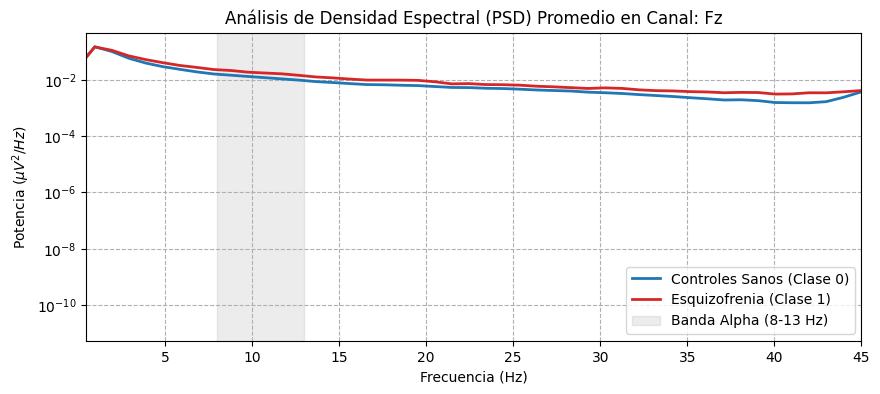

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# nombres_optimos
SFREQ = 250 # Frecuencia de muestreo (5s a 250Hz = 1250 muestras)

# ==============================================================================
# GRÁFICO 1: DENSIDAD DE POTENCIA ESPECTRAL (PSD) PROMEDIO
# ==============================================================================
def plot_clinical_psd(X, y, channels, sfreq, target_channel='Fz'):
    ch_idx = channels.index(target_channel)
    
    # Separar por clases
    x_sanos = X[y == 0, ch_idx, :]
    x_esquizo = X[y == 1, ch_idx, :]
    
    # Calcular Welch para todas las ventanas
    freqs, psd_sanos = welch(x_sanos, fs=sfreq, nperseg=256)
    freqs, psd_esquizo = welch(x_esquizo, fs=sfreq, nperseg=256)
    
    # Promedio e intervalos
    mean_sanos = np.mean(psd_sanos, axis=0)
    mean_esquizo = np.mean(psd_esquizo, axis=0)
    
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mean_sanos, label='Controles Sanos (Clase 0)', color='tab:blue', lw=2)
    plt.plot(freqs, mean_esquizo, label='Esquizofrenia (Clase 1)', color='tab:red', lw=2)
    
    # Resaltar bandas de interés médico
    plt.axvspan(8, 13, color='gray', alpha=0.15, label='Banda Alpha (8-13 Hz)')
    
    plt.title(f'Análisis de Densidad Espectral (PSD) Promedio en Canal: {target_channel}')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Potencia ($\mu V^2 / Hz$)')
    plt.xlim(0.5, 45) # Tu rango de filtrado pasa-banda
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()


# CANONICAL_CHANNELS = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 
# 'Pz', 'P4', 'T6', 'O1', 'O2']
# Ejecución de espectros (puedes cambiar 'Fz' por canales frontales o occipitales)
plot_clinical_psd(X, y, CANONICAL_CHANNELS, SFREQ, target_channel='Fz')

Los pacientes con esquizofrenia siempre **poseen una potencia superior en pacientes con esquizofrenia**, aunque no es significativo, este comportamiento se repite en todos los canales.

2. Comparación Temporal de Ventanas Promedio (Grand Average)

Es el promedio matemático de todas las ventanas de 5 segundos para un canal específico, contrastando ambas clases con una banda de sombreado (desviación estándar).

Ayuda a visualizar si hay picos, desorganización o amplitudes más atenuadas en los pacientes frente a los sujetos sanos.

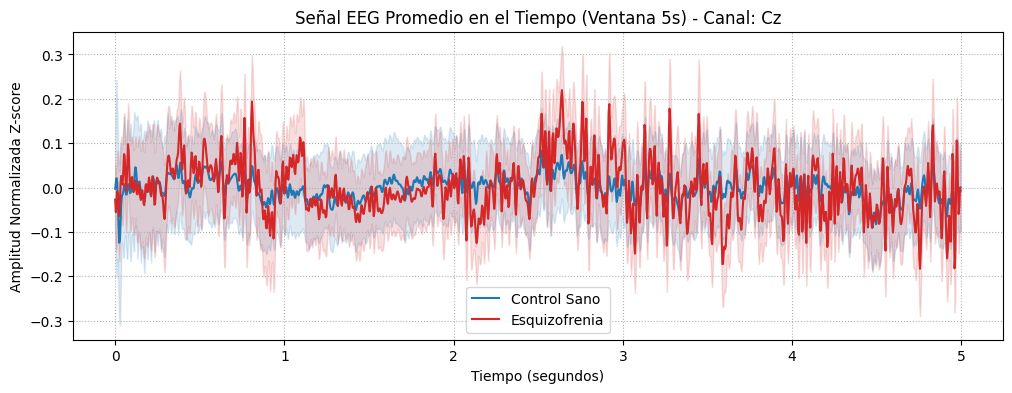

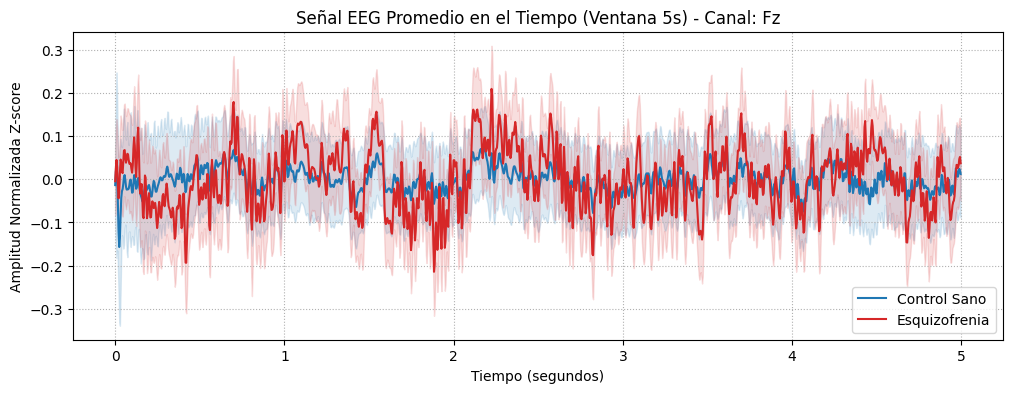

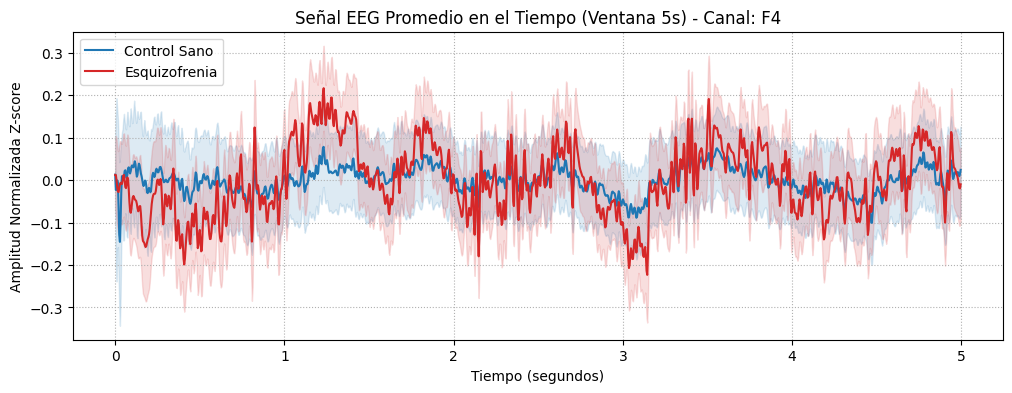

In [124]:
# ==============================================================================
# GRÁFICO 2: GRAND AVERAGE TEMPORAL
# ==============================================================================
def plot_grand_average(X, y, channels, target_channel='Cz'):
    ch_idx = channels.index(target_channel)
    time_vector = np.arange(X.shape[2]) / SFREQ # Vector de tiempo en segundos
    
    mean_sanos = np.mean(X[y == 0, ch_idx, :], axis=0)
    std_sanos = np.std(X[y == 0, ch_idx, :], axis=0) * 0.1 # Escala para sombreado sutil
    
    mean_esquizo = np.mean(X[y == 1, ch_idx, :], axis=0)
    std_esquizo = np.std(X[y == 1, ch_idx, :], axis=0) * 0.1
    
    plt.figure(figsize=(12, 4))
    plt.plot(time_vector, mean_sanos, label='Control Sano', color='tab:blue')
    plt.fill_between(time_vector, mean_sanos - std_sanos, mean_sanos + std_sanos, color='tab:blue', alpha=0.15)
    
    plt.plot(time_vector, mean_esquizo, label='Esquizofrenia', color='tab:red')
    plt.fill_between(time_vector, mean_esquizo - std_esquizo, mean_esquizo + std_esquizo, color='tab:red', alpha=0.15)
    
    plt.title(f'Señal EEG Promedio en el Tiempo (Ventana 5s) - Canal: {target_channel}')
    plt.xlabel('Tiempo (segundos)')
    plt.ylabel('Amplitud Normalizada Z-score')
    plt.grid(True, ls=':')
    plt.legend()
    plt.show()

# Ejecución de promedios temporales
plot_grand_average(X, y, CANONICAL_CHANNELS, target_channel='Cz')
plot_grand_average(X, y, CANONICAL_CHANNELS, target_channel='Fz')
plot_grand_average(X, y, CANONICAL_CHANNELS, target_channel='F4')

Se remarca la premicia de la inestabilidad **comprobada al hacer la prueba estadística**, se descarta el canal Cz, pues comparado con otras señales de específicas partes del cerebro, la varianza no es tan alta, y llega a ser completamente símil por muchos períodos de tiempo.

3. Matriz de Correlación Cruzada entre Canales (Conectividad Funcional)

Mapas de calor (Heatmaps) que evalúan cómo se correlacionan los sensores entre sí (sincronía inter-hemisférica).

En pacientes con esquizofrenia, la conectividad funcional suele estar alterada o disminuida (desconexión cortical), lo que se ve claramente al comparar los heatmaps de ambas clases.

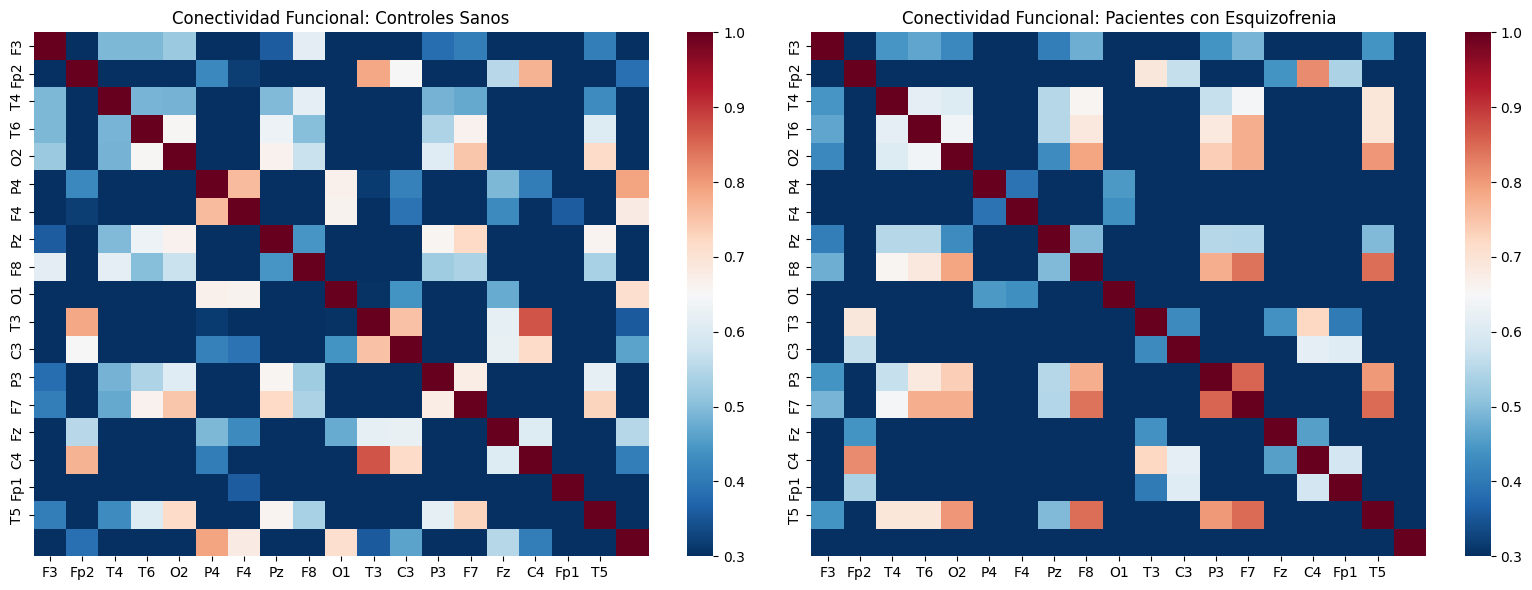

In [178]:
# ==============================================================================
# GRÁFICO 3: CONECTIVIDAD FUNCIONAL (MATRIZ DE CORRELACIÓN)
# ==============================================================================
def plot_connectivity_matrices(X, y, channels):
    # Calcular matriz de correlación promedio para Sanos
    sanos_data = X[y == 0]
    esquizo_data = X[y == 1]
    
    # Promediar correlaciones de Pearson entre ventanas
    corr_sanos = np.mean([np.corrcoef(sanos_data[i, :, :]) for i in range(min(100, len(sanos_data)))], axis=0)
    corr_esquizo = np.mean([np.corrcoef(esquizo_data[i, :, :]) for i in range(min(100, len(esquizo_data)))], axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(corr_sanos, xticklabels=channels, yticklabels=channels, cmap='RdBu_r', vmin=0.3, vmax=1.0, ax=axes[0], cbar=True)
    axes[0].set_title('Conectividad Funcional: Controles Sanos')
    
    sns.heatmap(corr_esquizo, xticklabels=channels, yticklabels=channels, cmap='RdBu_r', vmin=0.3, vmax=1.0, ax=axes[1], cbar=True)
    axes[1].set_title('Conectividad Funcional: Pacientes con Esquizofrenia')
    
    plt.tight_layout()
    plt.show()

# Ejecución de Conectividad Funcional
plot_connectivity_matrices(X, y, nombres_optimos) ## CANNONICAL_CHANNELS if you want 19 channels, nombres_optimos if you want filtered channels

Los cerebros sanos procesan la información de manera altamente sincrónica (correlaciones altas y estables entre canales); en la esquizofrenia, los módulos funcionales del cerebro pierden sincronía, provocando una caída drástica en la correlación inter-hemisférica. Por ello, es esperado que haya **menor correlación entre las señales de distintas partes del cerebro** en pacientes con esquizonfrenia.

4. Boxplots de Potencia Relativa por Banda de Frecuencia

Diagramas de caja que condensan la energía total acumulada en las bandas clínicas: Delta (0.5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz) y Beta (13-30 Hz).

-> Extrayendo potencias relativas por banda...


/tmp/ipykernel_9749/3766401380.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clase', y=band_name, data=df_boxplot, ax=axes[idx], palette='Set2')
/tmp/ipykernel_9749/3766401380.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clase', y=band_name, data=df_boxplot, ax=axes[idx], palette='Set2')
/tmp/ipykernel_9749/3766401380.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clase', y=band_name, data=df_boxplot, ax=axes[idx], palette='Set2')
/tmp/ipykernel_9749/3766401380.py:49: FutureWarning: 

Passing `palette` without a

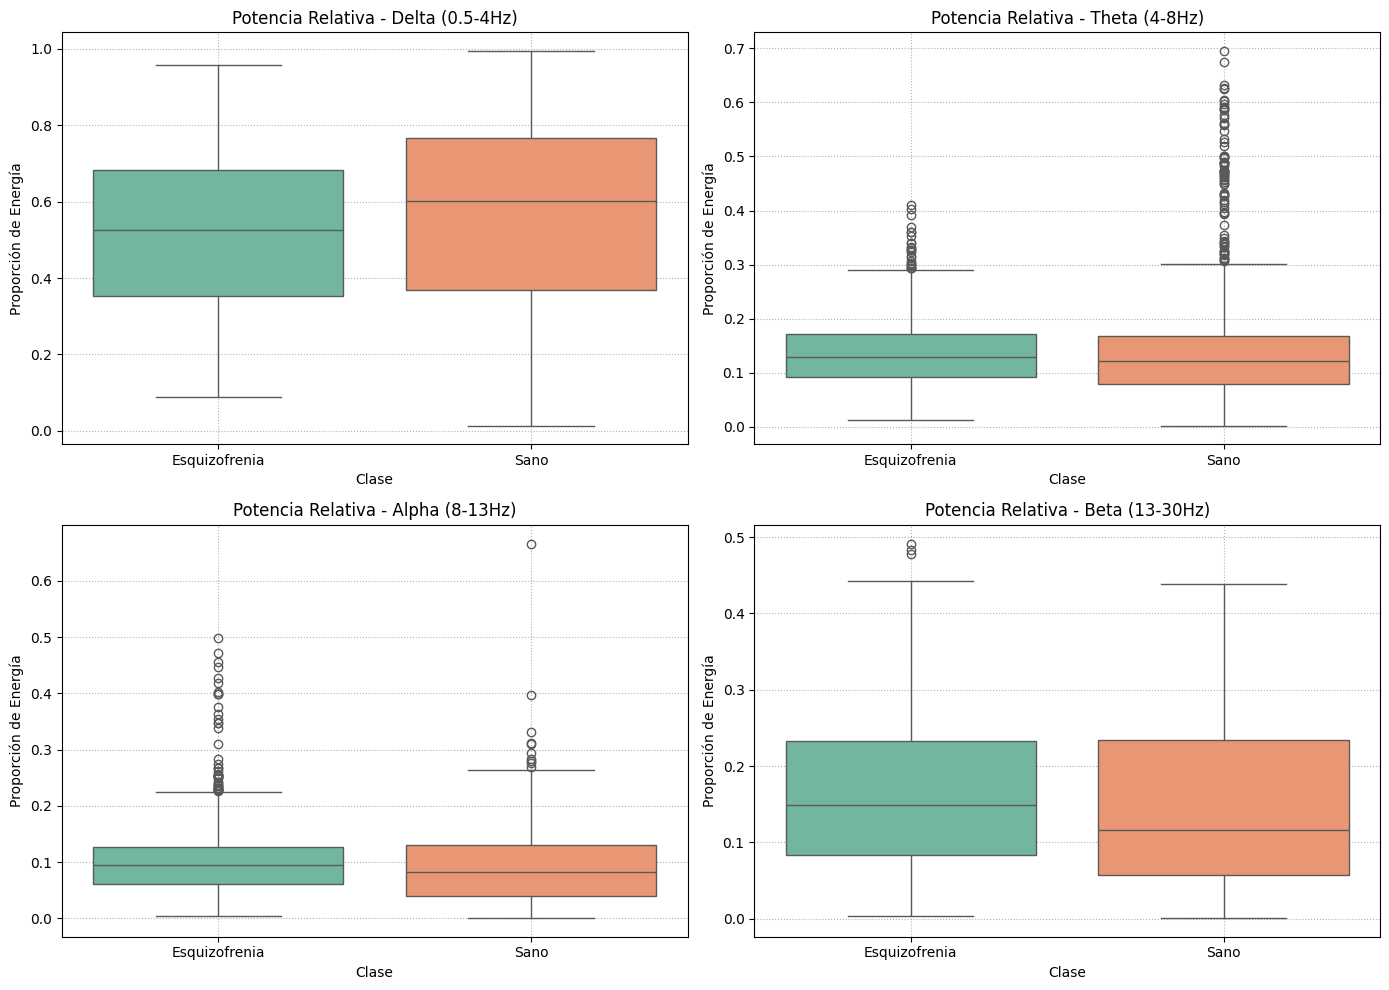

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

def plot_correct_band_boxplots(X, y, channels, sfreq=250):
    """
    Calcula la potencia relativa real para las 4 bandas principales
    evitando arreglos vacíos o errores de indexación.
    """
    # Definición estricta de las bandas neuroclínicas
    bands = {
        'Delta (0.5-4Hz)': (0.5, 4.0),
        'Theta (4-8Hz)': (4.0, 8.0),
        'Alpha (8-13Hz)': (8.0, 13.0),
        'Beta (13-30Hz)': (13.0, 30.0)
    }
    
    n_ventanas = X.shape[0]
    data_list = []
    
    print("-> Extrayendo potencias relativas por banda...")
    # Calculamos el espectro completo usando Welch por cada ventana (promediando canales)
    for i in range(n_ventanas):
        # Promedio espacial de los 18 canales para tener una métrica global por ventana
        signal_mean = np.mean(X[i, :, :], axis=0) 
        freqs, psd = welch(signal_mean, fs=sfreq, nperseg=256)
        
        total_power = np.sum(psd[(freqs >= 0.5) & (freqs <= 45.0)])
        
        row = {'Clase': 'Esquizofrenia' if y[i] == 1 else 'Sano'}
        for band_name, (f_min, f_max) in bands.items():
            # Máscara booleana correcta asegurando que encuentre frecuencias
            idx_band = (freqs >= f_min) & (freqs <= f_max)
            band_power = np.sum(psd[idx_band]) if np.any(idx_band) else 0.0
            # Potencia relativa
            row[band_name] = band_power / (total_power + 1e-9)
            
        data_list.append(row)
        
    df_boxplot = pd.DataFrame(data_list)
    
    # Graficar de forma iterativa las 4 bandas
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, band_name in enumerate(bands.keys()):
        sns.boxplot(x='Clase', y=band_name, data=df_boxplot, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'Potencia Relativa - {band_name}')
        axes[idx].set_ylabel('Proporción de Energía')
        axes[idx].grid(True, ls=':')
        
    plt.tight_layout()
    plt.show()

# Llamada en tu notebook v7
plot_correct_band_boxplots(X, y, nombres_optimos, sfreq=250)

Señales Delta [0.5-4]: rondan entre 0.5 la media, los sanos tienen un rango mayor.

Por otro lado, las señales > 4 Hz, tienen una proporción relativa al rededor de 0.1, y no hay tanta diferencia en el rango entre esquizofrénicos y sanos, haciéndolo más difíciles de comparar., pero siempre se cumple que **el rango es mayor en pacientes esquizofrénicos**.

### Fase 2. Selección inicial de una condición.

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, welch  # STFT y Welch siguen estando en SciPy
import pywt                           # Nueva librería para Wavelets

# =====================================================================
# 1. PARÁMETROS DE LA CONFIGURACIÓN TIEMPO-FRECUENCIA
# =====================================================================
SFREQ = 250.0  # Frecuencia unificada de nuestro tensor X (250 Hz)

print("Matriz X detectada en memoria con forma:", X.shape)
print("Mariz X filtrada detectada en memoria con forma:", X_filtered.shape)
print("Matriz X filtrada top6 detectada en memoria con forma:", X_top6.shape)
print("Generando extractores de imágenes tiempo-frecuencia...")

Matriz X detectada en memoria con forma: (5946, 19, 1250)
Mariz X filtrada detectada en memoria con forma: (5946, 18, 1250)
Matriz X filtrada top6 detectada en memoria con forma: (5946, 6, 1250)
Generando extractores de imágenes tiempo-frecuencia...


In [128]:
# =====================================================================
# 2. ENFOQUE A: GENERACIÓN DE ESPECTROGRAMAS (STFT)
# =====================================================================
def generate_stft_images(X_data, sfreq):
    """
    Transforma el tensor temporal X (Ventanas, Canales, Muestras) en un tensor
    de Espectrogramas 2D usando STFT de SciPy.
    """
    print("[*] Computando Espectrogramas STFT...")
    stft_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]  # Forma: (24, 1250)
        window_spectrograms = []
        
        for ch in range(window_channels.shape[0]):
            f, t_axis, Zxx = stft(window_channels[ch], fs=sfreq, nperseg=128, noverlap=64)
            magnitude = np.abs(Zxx)
            
            # Filtrar la banda de interés clínico de interés en Esquizofrenia (0.5 - 45 Hz)
            freq_mask = (f >= 0.5) & (f <= 45.0)
            magnitude_filtered = magnitude[freq_mask, :]
            window_spectrograms.append(magnitude_filtered)
            
        stft_list.append(np.array(window_spectrograms))
        
    return np.array(stft_list)

In [129]:
# =====================================================================
# 3. ENFOQUE B: GENERACIÓN DE ESCALOGRAMAS WAVELET ROBUSTOS (PyWavelets)
# =====================================================================
def generate_wavelet_images(X_data, sfreq):
    """
    Transforma el tensor temporal X en Escalogramas 2D usando pywt.cwt.
    Garantiza el mapeo exacto de las frecuencias analíticas (0.5 a 45 Hz).
    """
    print("[*] Computando Escalogramas Wavelet continuos mediante PyWavelets...")
    
    # Definimos las frecuencias lineales que representarán nuestro eje Y (40 filas verticales)
    frequencies = np.linspace(0.5, 45.0, num=40)
    
    # Seleccionamos la Wavelet de Morlet Compleja estándar en neurociencia: 'cmorB-C'
    # donde B es el ancho de banda (1.5) y C es la frecuencia central (1.0)
    wavelet_name = 'cmor1.5-1.0'
    
    # [NUEVO] Convertir las frecuencias físicas (Hz) a escalas matemáticas de PyWavelets
    # Nota: requiere frecuencias normalizadas dividiendo por sfreq
    scales = pywt.frequency2scale(wavelet_name, frequencies / sfreq)
    
    wavelet_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]
        window_escalograms = []
        
        for ch in range(window_channels.shape[0]):
            # pywt.cwt devuelve los coeficientes complejos y sus frecuencias asociadas
            coefs, freqs_computed = pywt.cwt(window_channels[ch], scales, wavelet_name, sampling_period=1.0/sfreq)
            
            # La magnitud absoluta representa la densidad de energía tiempo-frecuencia
            magnitude = np.abs(coefs)
            window_escalograms.append(magnitude)
            
        wavelet_list.append(np.array(window_escalograms))
        
    return np.array(wavelet_list)

In [ ]:
# =====================================================================
# 4. CONVERSIÓN Y PROCESAMIENTO MULTICANAL DE LOS NUEVOS TENSORES
# =====================================================================
# Generamos los bancos de imágenes para cada split por separado para evitar
# problemas de indexación con máscaras. Así cada tensor STFT tiene exactamente
# el mismo número de muestras que su correspondiente tensor temporal filtrado.
print("[*] Generando espectrogramas STFT para TRAIN...")
X_stft_train = generate_stft_images(X_train_filtered, SFREQ)

print("[*] Generando espectrogramas STFT para VAL...")
X_stft_val = generate_stft_images(X_val_filtered, SFREQ)

print("[*] Generando espectrogramas STFT para TEST...")
X_stft_test = generate_stft_images(X_test_filtered, SFREQ)

print("\n" + "="*60)
print("             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             ")
print("="*60)
print(f"[✓] Tensor STFT train listo: {X_stft_train.shape}  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
print(f"[✓] Tensor STFT val listo:   {X_stft_val.shape}  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
print(f"[✓] Tensor STFT test listo:  {X_stft_test.shape}  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
print("="*60)

[*] Generando espectrogramas STFT para TRAIN...
[*] Computando Espectrogramas STFT...
[*] Generando espectrogramas STFT para VAL...
[*] Computando Espectrogramas STFT...
[*] Generando espectrogramas STFT para TEST...
[*] Computando Espectrogramas STFT...

             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             
[✓] Tensor STFT train listo: (4333, 18, 23, 21)  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)
[✓] Tensor STFT val listo:   (749, 18, 23, 21)  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)
[✓] Tensor STFT test listo:  (864, 18, 23, 21)  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)


[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.


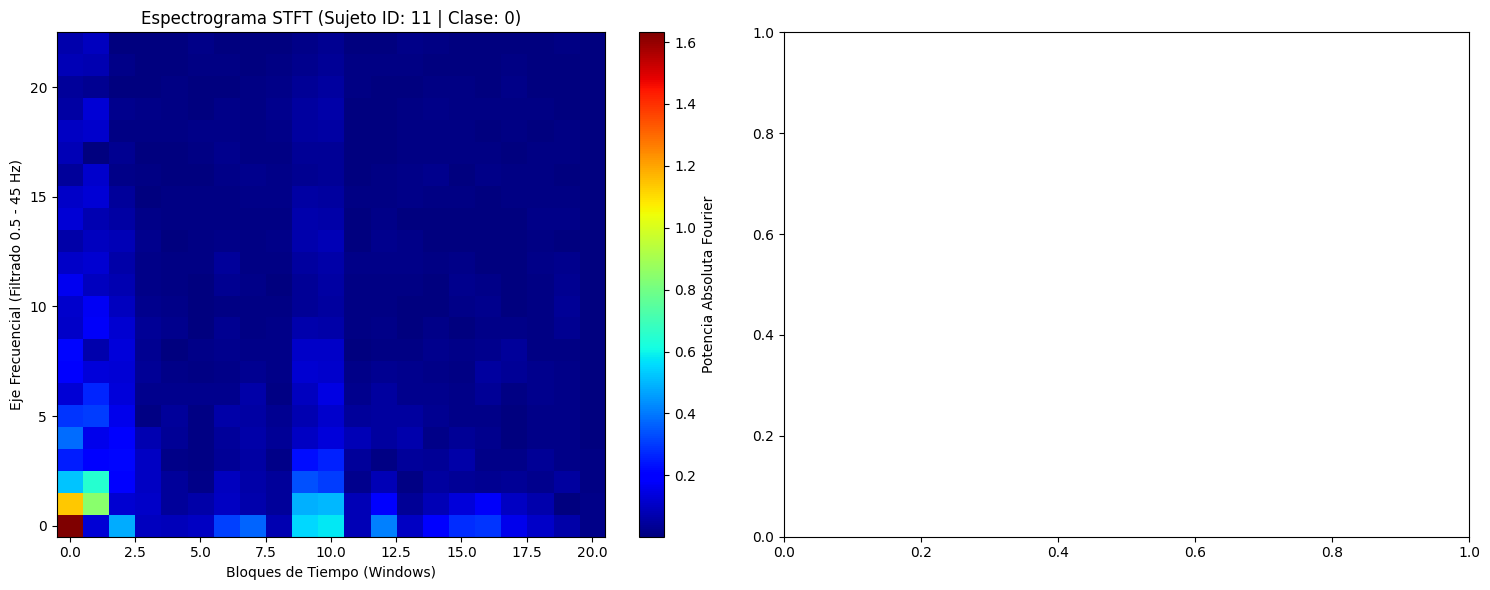

In [131]:
# =====================================================================
# 5. GENERACIÓN DE LA MUESTRA GRÁFICA (Guardado seguro en disco)
# =====================================================================
# Evaluamos visualmente el primer canal del primer paciente para el informe de Overleaf
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Graficar Espectrograma STFT
im0 = axs[0].imshow(X_stft_train[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[0].set_title(f"Espectrograma STFT (Sujeto ID: {groups_train[0]} | Clase: {y_train[0]})")
axs[0].set_xlabel("Bloques de Tiempo (Windows)")
axs[0].set_ylabel("Eje Frecuencial (Filtrado 0.5 - 45 Hz)")
fig.colorbar(im0, ax=axs[0], label="Potencia Absoluta Fourier")

# Graficar Escalograma Wavelet (PyWavelets) — comentado por ahora
'''
im1 = axs[1].imshow(X_cwt[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[1].set_title(f"Escalograma CWT PyWavelets (Sujeto ID: {groups_train[0]} | Clase: {y_train[0]})")
axs[1].set_xlabel("Muestras de Tiempo Continuas (Samples)")
axs[1].set_ylabel("Frecuencia Wavelet (0.5 - 45 Hz)")
fig.colorbar(im1, ax=axs[1], label="Magnitud de Coeficientes Morlet")
'''

plt.tight_layout()
# Guardamos la gráfica para evitar el comando interactivo plt.show() y asegurar reproducibilidad
plt.savefig("muestras_tiempo_frecuencia_eeg.pdf", dpi=300)
print("[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.")

### Fase 2 (cierre). Aplicar el split a las imágenes y normalizarlas

In [132]:
# =====================================================================
# 6. APLICAR EL SPLIT A LOS TENSORES STFT (YA HECHO EN FASE ANTERIOR)
# =====================================================================
# Ya hemos generado X_stft_train, X_stft_val, X_stft_test directamente desde
# X_train_filtered, X_val_filtered, X_test_filtered en la fase anterior.
# No necesitamos aplicar máscaras ahora porque los tensores ya están correctamente
# separados y tienen exactamente la misma cantidad de muestras que sus
# correspondientes tensores temporales (X_train_filtered, X_val_filtered, X_test_filtered).

print(f"[OK] X_stft dividido -> train: {X_stft_train.shape} | val: {X_stft_val.shape} | test: {X_stft_test.shape}")
print(f"[OK] Verificación: Los tamaños de muestras coinciden")
print(f"     X_train_filtered: {X_train_filtered.shape[0]} muestras | X_stft_train: {X_stft_train.shape[0]} muestras")
print(f"     X_val_filtered: {X_val_filtered.shape[0]} muestras | X_stft_val: {X_stft_val.shape[0]} muestras")
print(f"     X_test_filtered: {X_test_filtered.shape[0]} muestras | X_stft_test: {X_stft_test.shape[0]} muestras")

[OK] X_stft dividido -> train: (4333, 18, 23, 21) | val: (749, 18, 23, 21) | test: (864, 18, 23, 21)
[OK] Verificación: Los tamaños de muestras coinciden
     X_train_filtered: 4333 muestras | X_stft_train: 4333 muestras
     X_val_filtered: 749 muestras | X_stft_val: 749 muestras
     X_test_filtered: 864 muestras | X_stft_test: 864 muestras


In [133]:
# =====================================================================
# 7. NORMALIZACION DE LAS IMAGENES STFT (compresion log + z-score por canal)
# =====================================================================
# La magnitud de un espectrograma tiene un rango dinamico muy amplio (unos
# pocos bins concentran casi toda la energia), lo que dificulta el entrenamiento
# de una CNN. Aplicamos compresion logaritmica (log1p) y normalizamos con la
# media/desviacion calculadas SOLO en train (para no filtrar informacion de
# val/test), por canal, para mantener escalas comparables entre los canales EEG.

X_stft_train_log = np.log1p(X_stft_train)
X_stft_val_log   = np.log1p(X_stft_val)
X_stft_test_log  = np.log1p(X_stft_test)

# EstadiX, CANOsticos por canal calculados unicamente con train
stft_mean = X_stft_train_log.mean(axis=(0, 2, 3), keepdims=True)
stft_std  = X_stft_train_log.std(axis=(0, 2, 3), keepdims=True) + 1e-8

X_stft_train_norm = (X_stft_train_log - stft_mean) / stft_std
X_stft_val_norm   = (X_stft_val_log   - stft_mean) / stft_std
X_stft_test_norm  = (X_stft_test_log  - stft_mean) / stft_std

print("[OK] Imagenes STFT normalizadas (log1p + z-score por canal, ajustado solo con train).")
print(f"    Rango train tras normalizacion: [{X_stft_train_norm.min():.2f}, {X_stft_train_norm.max():.2f}]")

[OK] Imagenes STFT normalizadas (log1p + z-score por canal, ajustado solo con train).
    Rango train tras normalizacion: [-0.92, 13.06]


## Fase 3. Extracción y selección de características clásicas (`tsfresh`)

> Si no tienes instalado `tsfresh`, corre `pip install tsfresh` antes de seguir.

In [183]:
# =====================================================================
# 1. IMPORTS PARA LA RAMA CLASICA (tsfresh)
# =====================================================================
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import MinimalFCParameters, EfficientFCParameters, ComprehensiveFCParameters
from tsfresh.utilities.dataframe_functions import impute

# [NOTA] Usamos MinimalFCParameters (~10 caracteristicas por canal) en vez de
# EfficientFCParameters (cientos de caracteristicas) porque con 19 canales y
# miles de ventanas, un set extenso es muy costoso en una maquina personal.
# Si tu hardware lo permite, puedes cambiar a EfficientFCParameters() despues
# y comparar si mejora el desempeno.
#FC_PARAMETERS = MinimalFCParameters()
FC_PARAMETERS = EfficientFCParameters()  # [FIX] Cambio a EfficientFCParameters para más características
N_JOBS_TSFRESH = 0  # 0 = sin multiprocessing (mas estable en notebooks); sube este valor si tienes nucleos libres


In [135]:
# =====================================================================
# 2. FUNCION DE EXTRACCION tsfresh CANAL POR CANAL
# =====================================================================
def extract_tsfresh_features(X_split, channel_names, fc_parameters, n_jobs=0):
    """
    Extrae caracteristicas tsfresh CANAL POR CANAL (en vez de un unico
    dataframe largo multivariado) para mantener el uso de memoria bajo
    control: cada canal se procesa por separado y los resultados se
    concatenan horizontalmente, prefijando cada caracteristica con el
    nombre del canal de origen (ej. 'Fp1__mean', 'O2__variance').
    """
    n_windows, n_channels, n_samples = X_split.shape
    feature_blocks = []

    for ch_idx, ch_name in enumerate(channel_names):
        ids = np.repeat(np.arange(n_windows), n_samples)
        times = np.tile(np.arange(n_samples), n_windows)
        values = X_split[:, ch_idx, :].reshape(-1)
        df_long = pd.DataFrame({'id': ids, 'time': times, 'value': values})

        feats = extract_features(
            df_long, column_id='id', column_sort='time', column_value='value',
            default_fc_parameters=fc_parameters, n_jobs=n_jobs, disable_progressbar=True
        )
        feats = feats.add_prefix(f"{ch_name}__")
        feature_blocks.append(feats)
        print(f"    [{ch_idx + 1}/{n_channels}] Canal {ch_name} -> {feats.shape[1]} caracteristicas")

    return pd.concat(feature_blocks, axis=1)


In [184]:
# =====================================================================
# 3. EXTRACCION SOBRE TRAIN / VAL / TEST (puede tardar varios minutos)
# =====================================================================
print("[*] Extrayendo caracteristicas tsfresh -- TRAIN...")
feats_train_raw = extract_tsfresh_features(X_train_top6, nombres_top6, FC_PARAMETERS, N_JOBS_TSFRESH)

print("\n[*] Extrayendo caracteristicas tsfresh -- VAL...")
feats_val_raw = extract_tsfresh_features(X_val_top6, nombres_top6, FC_PARAMETERS, N_JOBS_TSFRESH)

print("\n[*] Extrayendo caracteristicas tsfresh -- TEST...")
feats_test_raw = extract_tsfresh_features(X_test_top6, nombres_top6, FC_PARAMETERS, N_JOBS_TSFRESH)

print(f"\n[OK] Caracteristicas extraidas por ventana: {feats_train_raw.shape[1]}")

[*] Extrayendo caracteristicas tsfresh -- TRAIN...
    [1/6] Canal F3 -> 777 caracteristicas
    [2/6] Canal Fp2 -> 777 caracteristicas


KeyboardInterrupt: 

In [137]:
# =====================================================================
# 4. IMPUTACION Y SELECCION DE CARACTERISTICAS (ajustada SOLO con train)
# =====================================================================
# tsfresh puede generar NaN/inf en senales casi constantes (ventanas con muy
# poca varianza); impute() las reemplaza con la mediana de cada columna.
impute(feats_train_raw)
impute(feats_val_raw)
impute(feats_test_raw)

# select_features usa pruebas de hipotesis (relevancia estadistica respecto a y)
# para descartar caracteristicas no informativas. Se ajusta SOLO con train para
# no filtrar informacion de val/test al elegir que caracteristicas conservar.
feats_train_selected = select_features(feats_train_raw, pd.Series(y_train))
selected_columns = feats_train_selected.columns

feats_val_selected  = feats_val_raw[selected_columns]
feats_test_selected = feats_test_raw[selected_columns]

print(f"[OK] Caracteristicas antes de seleccion: {feats_train_raw.shape[1]}")
print(f"[OK] Caracteristicas despues de seleccion: {feats_train_selected.shape[1]}")

[OK] Caracteristicas antes de seleccion: 180
[OK] Caracteristicas despues de seleccion: 108


Eliminar features por correlación

In [138]:
# ==========================================
# NUEVO: 3. Filtro de Alta Correlación
# ==========================================
def obtener_columnas_altamente_correlacionadas(df_features, threshold=0.85):
    print(f"Columnas tras tsfresh: {df_features.shape[1]}")
    corr_matrix = df_features.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    print(f"Columnas eliminadas por redundancia (> {threshold}): {len(to_drop)}")
    return to_drop

# Calculamos qué columnas son redundantes SOLO viendo TRAIN
columnas_redundantes = obtener_columnas_altamente_correlacionadas(feats_train_selected, threshold=0.85)

# Eliminamos esas mismas columnas de los tres conjuntos
X_train_claro = feats_train_selected.drop(columns=columnas_redundantes)
X_val_claro = feats_val_selected.drop(columns=columnas_redundantes)
X_test_claro = feats_test_selected.drop(columns=columnas_redundantes)

print(f"Columnas FINALES para entrenar: {X_train_claro.shape[1]}")

Columnas tras tsfresh: 108
Columnas eliminadas por redundancia (> 0.85): 42
Columnas FINALES para entrenar: 66


## Fase 4a. Modelos clásicos (SVM, XGBoost, Random Forest, Regresión Logística)

In [139]:
# =====================================================================
# 1. FUNCION DE METRICAS REUTILIZABLE (clasicos y deep learning)
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score,
                              confusion_matrix)

def compute_metrics(y_true, y_pred, y_proba=None):
    """Calcula el set de metricas pedido por el proyecto: accuracy, precision,
    recall/sensibilidad, specificity, F1, balanced accuracy, ROC-AUC y matriz
    de confusion."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall_sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }

def print_metrics(name, metrics):
    print(f"[{name}] Acc={metrics['accuracy']:.3f} | F1={metrics['f1']:.3f} | "
          f"ROC-AUC={metrics['roc_auc']:.3f} | Sens={metrics['recall_sensitivity']:.3f} | "
          f"Spec={metrics['specificity']:.3f}")


In [ ]:
# =====================================================================
# 2. ENTRENAMIENTO DE MODELOS CLASICOS (sobre las caracteristicas tsfresh seleccionadas)
# =====================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

RANDOM_STATE = 42

# Escalamos las caracteristicas (necesario para SVM/Regresion Logistica; no
# afecta a los modelos basados en arboles). El escalador se ajusta SOLO con train.
scaler = StandardScaler()
X_feat_train = scaler.fit_transform(X_train_claro)
X_feat_val   = scaler.transform(X_val_claro)
X_feat_test  = scaler.transform(X_test_claro)

classical_models = {
    'SVM':               SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':            XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':           XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM':          LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
}

classical_val_metrics = {}
fitted_classical_models = {}

for name, model in classical_models.items():
    model.fit(X_feat_train, y_train)
    y_pred_val = model.predict(X_feat_val)
    y_proba_val = model.predict_proba(X_feat_val)[:, 1]

    metrics = compute_metrics(y_val, y_pred_val, y_proba_val)
    classical_val_metrics[name] = metrics
    fitted_classical_models[name] = model
    print_metrics(name, metrics)

[SVM] Acc=0.761 | F1=0.757 | ROC-AUC=0.840 | Sens=0.848 | Spec=0.693
[RandomForest] Acc=0.801 | F1=0.802 | ROC-AUC=0.866 | Sens=0.918 | Spec=0.710
[XGBoost] Acc=0.814 | F1=0.805 | ROC-AUC=0.903 | Sens=0.872 | Spec=0.769
[LogisticRegression] Acc=0.713 | F1=0.708 | ROC-AUC=0.755 | Sens=0.793 | Spec=0.650
[LightGBM] [Info] Number of positive: 2294, number of negative: 2039
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16656
[LightGBM] [Info] Number of data points in the train set: 4333, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] Acc=0.837 | F1=0.831 | ROC-AUC=0.921 | Sens=0.909 | Spec=0.781


/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generando análisis de explicabilidad con SHAP para XGBoost...


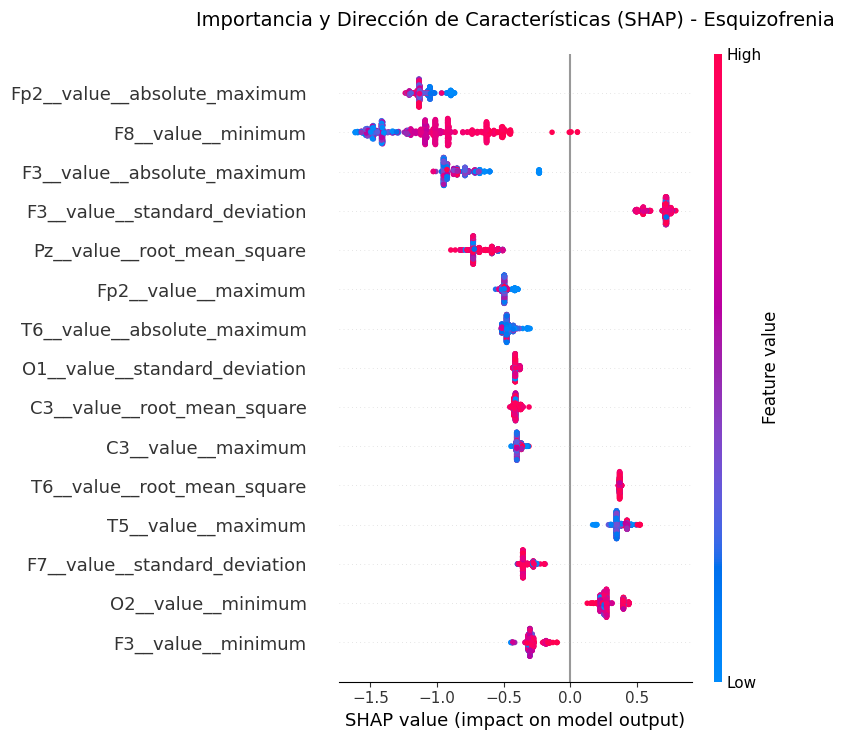

In [156]:
# --- NUEVA Celda 33.5 (Análisis de Explicabilidad con SHAP) ---
import shap
import matplotlib.pyplot as plt

print("Generando análisis de explicabilidad con SHAP para XGBoost...")

# 1. Crear el explainer usando tu modelo entrenado basado en árboles
explainer = shap.TreeExplainer(classical_models['XGBoost'])

# 2. Calcular los valores SHAP usando el conjunto de validación o entrenamiento limpio
# Usamos X_val_claro para ver cómo el modelo toma decisiones en datos que no ha visto
shap_values = explainer(X_val_claro)

# 3. Graficar el Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_claro, max_display=15, show=False)
plt.title("Importancia y Dirección de Características (SHAP) - Esquizofrenia", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

los prefijos de las variables más importantes: F4, F3, F7, T3, T4, Fp1. ¡Todos son frontales y temporales! Esto cuadra perfecto con la teoría médica de la esquizofrenia.

**Filtrar por Shap Values**

In [164]:
import numpy as np

# 1. Calculamos la importancia absoluta media de cada feature según SHAP
# shap_values es un objeto Explanation, necesitamos extraer los valores con .values
shap_sum = np.abs(shap_values.values).mean(axis=0)

# 2. Creamos un DataFrame para ver el ranking
importancia_df = pd.DataFrame({
    'Feature': X_val_claro.columns,
    'SHAP_Importance': shap_sum
}).sort_values(by='SHAP_Importance', ascending=False)

# 3. Nos quedamos solo con el shap value > 0.1
top_features = importancia_df[importancia_df['SHAP_Importance'] > 0.1]['Feature'].tolist()

In [167]:
importancia_df[importancia_df['SHAP_Importance'] > 0.1]['Feature'].tolist()

['Fp2__value__absolute_maximum',
 'F8__value__minimum',
 'F3__value__absolute_maximum',
 'F3__value__standard_deviation',
 'Pz__value__root_mean_square',
 'Fp2__value__maximum',
 'T6__value__absolute_maximum',
 'O1__value__standard_deviation',
 'C3__value__root_mean_square',
 'C3__value__maximum',
 'T6__value__root_mean_square',
 'T5__value__maximum',
 'F7__value__standard_deviation',
 'O2__value__minimum',
 'F3__value__minimum',
 'F8__value__maximum',
 'F4__value__standard_deviation',
 'C3__value__absolute_maximum',
 'Fp2__value__minimum',
 'F7__value__minimum',
 'C3__value__minimum',
 'F4__value__maximum',
 'F8__value__root_mean_square',
 'C4__value__absolute_maximum',
 'F7__value__absolute_maximum',
 'P4__value__standard_deviation',
 'T4__value__minimum',
 'Pz__value__minimum',
 'Fz__value__minimum',
 'T3__value__root_mean_square',
 'P3__value__maximum',
 'T4__value__variance',
 'Fp1__value__minimum']

In [168]:
X_train_final = X_train_claro[top_features]
X_val_final = X_val_claro[top_features]
X_test_final = X_test_claro[top_features]

print(f"Dataset reducido a las {len(top_features)} características más importantes según SHAP.")

Dataset reducido a las 33 características más importantes según SHAP.


In [169]:
# =====================================================================
# 2. ENTRENAMIENTO DE MODELOS CLASICOS (sobre las caracteristicas tsfresh seleccionadas)
# =====================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

RANDOM_STATE = 42

# Escalamos las caracteristicas (necesario para SVM/Regresion Logistica; no
# afecta a los modelos basados en arboles). El escalador se ajusta SOLO con train.
#scaler = StandardScaler() viene de arriba
X_feat_train_final = scaler.fit_transform(X_train_final)
X_feat_val_final   = scaler.transform(X_val_final)
X_feat_test_final  = scaler.transform(X_test_final)

classical_models = {
    'SVM':               SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':            XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':           XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM':          LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
}

classical_val_metrics = {}
fitted_classical_models = {}

for name, model in classical_models.items():
    model.fit(X_feat_train_final, y_train)
    y_pred_val = model.predict(X_feat_val_final)
    y_proba_val = model.predict_proba(X_feat_val_final)[:, 1]

    metrics = compute_metrics(y_val, y_pred_val, y_proba_val)
    classical_val_metrics[name] = metrics
    fitted_classical_models[name] = model
    print_metrics(name, metrics)

[SVM] Acc=0.752 | F1=0.754 | ROC-AUC=0.823 | Sens=0.866 | Spec=0.662
[RandomForest] Acc=0.797 | F1=0.801 | ROC-AUC=0.880 | Sens=0.930 | Spec=0.693
[XGBoost] Acc=0.780 | F1=0.773 | ROC-AUC=0.877 | Sens=0.854 | Spec=0.721
[LogisticRegression] Acc=0.718 | F1=0.720 | ROC-AUC=0.751 | Sens=0.824 | Spec=0.636
[LightGBM] [Info] Number of positive: 2294, number of negative: 2039
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8414
[LightGBM] [Info] Number of data points in the train set: 4333, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] Acc=0.810 | F1=0.804 | ROC-AUC=0.896 | Sens=0.884 | Spec=0.752


/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Fase 4b. Modelos de deep learning (CNN propia y transfer learning) sobre espectrogramas STFT

Recomendación: tener las liberías de pytorch y cuda correctamente.

In [141]:
# =====================================================================
# 1. IMPORTS Y DATASET DE PYTORCH PARA LOS ESPECTROGRAMAS STFT
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de entrenamiento: {device}")

class STFTDataset(Dataset):
    """Envuelve el tensor de espectrogramas (N, canales, freq, tiempo) y las
    etiquetas para usarlos con DataLoader de PyTorch."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_loader = DataLoader(STFTDataset(X_stft_train_norm, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(STFTDataset(X_stft_val_norm, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(STFTDataset(X_stft_test_norm, y_test), batch_size=BATCH_SIZE, shuffle=False)


[INFO] Dispositivo de entrenamiento: cuda


In [142]:
X_stft_train_norm.shape, X_stft_val_norm.shape, X_stft_test_norm.shape

((4333, 18, 23, 21), (749, 18, 23, 21), (864, 18, 23, 21))

In [143]:
# =====================================================================
# 2. FUNCIONES GENERICAS DE ENTRENAMIENTO Y EVALUACION (reutilizables para ambos modelos DL)
# =====================================================================
def train_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3, patience=5):
    """Entrena con early stopping sobre la perdida de validacion. Devuelve el
    modelo con los mejores pesos encontrados en validacion."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb).squeeze(1)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"  Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  [INFO] Early stopping en epoch {epoch} (sin mejora en {patience} epocas).")
                break

    model.load_state_dict(best_state)
    return model


def evaluate_model(model, loader):
    """Corre el modelo en modo evaluacion y devuelve (y_true, y_pred, y_proba)."""
    model.eval()
    all_true, all_proba = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb).squeeze(1)
            proba = torch.sigmoid(logits).cpu().numpy()
            all_proba.extend(proba)
            all_true.extend(yb.numpy())
    all_true = np.array(all_true)
    all_proba = np.array(all_proba)
    all_pred = (all_proba >= 0.5).astype(int)
    return all_true, all_pred, all_proba


In [144]:
# =====================================================================
# 3. CNN PROPIA (arquitectura base entrenada desde cero)
# =====================================================================
class SimpleEEGCNN(nn.Module):
    """CNN pequena que toma el espectrograma multicanal (18 canales EEG,
    freq, tiempo) tratando los 18 canales como la dimension de 'canales de
    imagen' (analogo a RGB pero con 18 canales)."""
    def __init__(self, n_channels=18):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

print("[*] Entrenando CNN propia...")
cnn_model = SimpleEEGCNN(n_channels=len(nombres_optimos))
cnn_model = train_model(cnn_model, train_loader, val_loader, n_epochs=30, lr=1e-3, patience=6)

y_val_true, y_val_pred, y_val_proba = evaluate_model(cnn_model, val_loader)
cnn_val_metrics = compute_metrics(y_val_true, y_val_pred, y_val_proba)
print_metrics("CNN propia", cnn_val_metrics)


[*] Entrenando CNN propia...
  Epoch 01 | train_loss=0.5297 | val_loss=0.5124
  Epoch 02 | train_loss=0.4101 | val_loss=0.5412
  Epoch 03 | train_loss=0.3578 | val_loss=0.6128
  Epoch 04 | train_loss=0.3182 | val_loss=0.5367
  Epoch 05 | train_loss=0.2787 | val_loss=0.6652
  Epoch 06 | train_loss=0.2681 | val_loss=0.6423
  Epoch 07 | train_loss=0.2507 | val_loss=0.6461
  [INFO] Early stopping en epoch 7 (sin mejora en 6 epocas).
[CNN propia] Acc=0.785 | F1=0.785 | ROC-AUC=0.831 | Sens=0.894 | Spec=0.700


In [145]:
# =====================================================================
# 4. RESNET18 CON TRANSFER LEARNING (adaptado a 18 canales de entrada)
# =====================================================================
# ResNet18 viene preentrenado con imagenes RGB (3 canales) de ~224x224.
# Reemplazamos su primera convolucion para aceptar 18 canales, inicializando
# los pesos nuevos como el promedio de los 3 filtros RGB originales repetido
# 18 veces (conservamos parte del conocimiento preentrenado en vez de partir
# de cero). Tambien redimensionamos el espectrograma a 64x64 antes de entrar
# a la red: sin esto, el downsampling agresivo de ResNet reduciria nuestras
# imagenes (23x21) a un tamano degenerado de 1x1 en pocas capas.
import torchvision.models as tv_models

def build_resnet18_for_eeg(n_channels):
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)

    old_conv = model.conv1
    new_conv = nn.Conv2d(n_channels, old_conv.out_channels,
                          kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride,
                          padding=old_conv.padding,
                          bias=False)
    with torch.no_grad():
        avg_weight = old_conv.weight.mean(dim=1, keepdim=True)  # promedio sobre los 3 canales RGB
        new_conv.weight[:] = avg_weight.repeat(1, n_channels, 1, 1)
    model.conv1 = new_conv
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model


class ResNetEEGWrapper(nn.Module):
    """Redimensiona el espectrograma a una resolucion mas adecuada para una
    arquitectura disenada para imagenes mas grandes."""
    def __init__(self, base_model, target_size=(64, 64)):
        super().__init__()
        self.base_model = base_model
        self.target_size = target_size

    def forward(self, x):
        x = F.interpolate(x, size=self.target_size, mode='bilinear', align_corners=False)
        return self.base_model(x)


print("[*] Entrenando ResNet18 (transfer learning, conv1 adaptada a 18 canales)...")
resnet_model = ResNetEEGWrapper(build_resnet18_for_eeg(n_channels=len(nombres_optimos)), target_size=(64, 64))
resnet_model = train_model(resnet_model, train_loader, val_loader, n_epochs=20, lr=1e-4, patience=5)

y_val_true, y_val_pred, y_val_proba = evaluate_model(resnet_model, val_loader)
resnet_val_metrics = compute_metrics(y_val_true, y_val_pred, y_val_proba)
print_metrics("ResNet18 (transfer)", resnet_val_metrics)


[*] Entrenando ResNet18 (transfer learning, conv1 adaptada a 18 canales)...
  Epoch 01 | train_loss=0.5172 | val_loss=0.4142
  Epoch 02 | train_loss=0.3205 | val_loss=0.3592
  Epoch 03 | train_loss=0.2254 | val_loss=0.4362
  Epoch 04 | train_loss=0.1674 | val_loss=0.5123
  Epoch 05 | train_loss=0.1489 | val_loss=0.5628
  Epoch 06 | train_loss=0.1199 | val_loss=0.5375
  Epoch 07 | train_loss=0.1018 | val_loss=0.5402
  [INFO] Early stopping en epoch 7 (sin mejora en 5 epocas).
[ResNet18 (transfer)] Acc=0.821 | F1=0.820 | ROC-AUC=0.914 | Sens=0.927 | Spec=0.738


## Fase 5. Comparación experimental final (evaluación en TEST)

In [171]:
# =====================================================================
# 1. EVALUACION FINAL DE TODOS LOS MODELOS SOBRE EL CONJUNTO DE TEST
# =====================================================================
# Hasta ahora usamos VAL para monitorear entrenamiento/seleccion de modelos.
# El conjunto TEST se reserva para esta unica evaluacion final, nunca antes.

final_results = {}

# Modelos clasicos
for name, model in fitted_classical_models.items():
    y_pred = model.predict(X_feat_test_final)
    y_proba = model.predict_proba(X_feat_test_final)[:, 1]
    final_results[name] = compute_metrics(y_test, y_pred, y_proba)

# Modelos deep learning
y_true_cnn, y_pred_cnn, y_proba_cnn = evaluate_model(cnn_model, test_loader)
final_results['CNN propia'] = compute_metrics(y_true_cnn, y_pred_cnn, y_proba_cnn)

y_true_resnet, y_pred_resnet, y_proba_resnet = evaluate_model(resnet_model, test_loader)
final_results['ResNet18 (transfer)'] = compute_metrics(y_true_resnet, y_pred_resnet, y_proba_resnet)

for name, metrics in final_results.items():
    print_metrics(name, metrics)

/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/germain/Documentos/Python_Projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[SVM] Acc=0.661 | F1=0.666 | ROC-AUC=0.728 | Sens=0.775 | Spec=0.573
[RandomForest] Acc=0.686 | F1=0.694 | ROC-AUC=0.764 | Sens=0.814 | Spec=0.587
[XGBoost] Acc=0.688 | F1=0.690 | ROC-AUC=0.688 | Sens=0.796 | Spec=0.604
[LogisticRegression] Acc=0.711 | F1=0.722 | ROC-AUC=0.747 | Sens=0.859 | Spec=0.595
[LightGBM] Acc=0.684 | F1=0.687 | ROC-AUC=0.693 | Sens=0.793 | Spec=0.600
[CNN propia] Acc=0.709 | F1=0.721 | ROC-AUC=0.780 | Sens=0.862 | Spec=0.591
[ResNet18 (transfer)] Acc=0.713 | F1=0.731 | ROC-AUC=0.721 | Sens=0.894 | Spec=0.573


In [172]:
# =====================================================================
# 2. TABLA COMPARATIVA FINAL
# =====================================================================
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': m['accuracy'],
        'Precision': m['precision'],
        'Sensibilidad (Recall)': m['recall_sensitivity'],
        'Especificidad': m['specificity'],
        'F1-score': m['f1'],
        'Balanced Accuracy': m['balanced_accuracy'],
        'ROC-AUC': m['roc_auc'],
    }
    for name, m in final_results.items()
}).T.sort_values('F1-score', ascending=False)

print(comparison_df.round(3))
comparison_df.to_csv('comparacion_final_modelos.csv')
print("\n[OK] Tabla guardada en 'comparacion_final_modelos.csv'")

                     Accuracy  Precision  Sensibilidad (Recall)  \
ResNet18 (transfer)     0.713      0.618                  0.894   
LogisticRegression      0.711      0.622                  0.859   
CNN propia              0.709      0.620                  0.862   
RandomForest            0.686      0.604                  0.814   
XGBoost                 0.688      0.609                  0.796   
LightGBM                0.684      0.605                  0.793   
SVM                     0.661      0.584                  0.775   

                     Especificidad  F1-score  Balanced Accuracy  ROC-AUC  
ResNet18 (transfer)          0.573     0.731              0.733    0.721  
LogisticRegression           0.595     0.722              0.727    0.747  
CNN propia                   0.591     0.721              0.727    0.780  
RandomForest                 0.587     0.694              0.701    0.764  
XGBoost                      0.604     0.690              0.700    0.688  
LightGBM     

[OK] Matrices de confusion exportadas a 'matrices_confusion_finales.pdf'


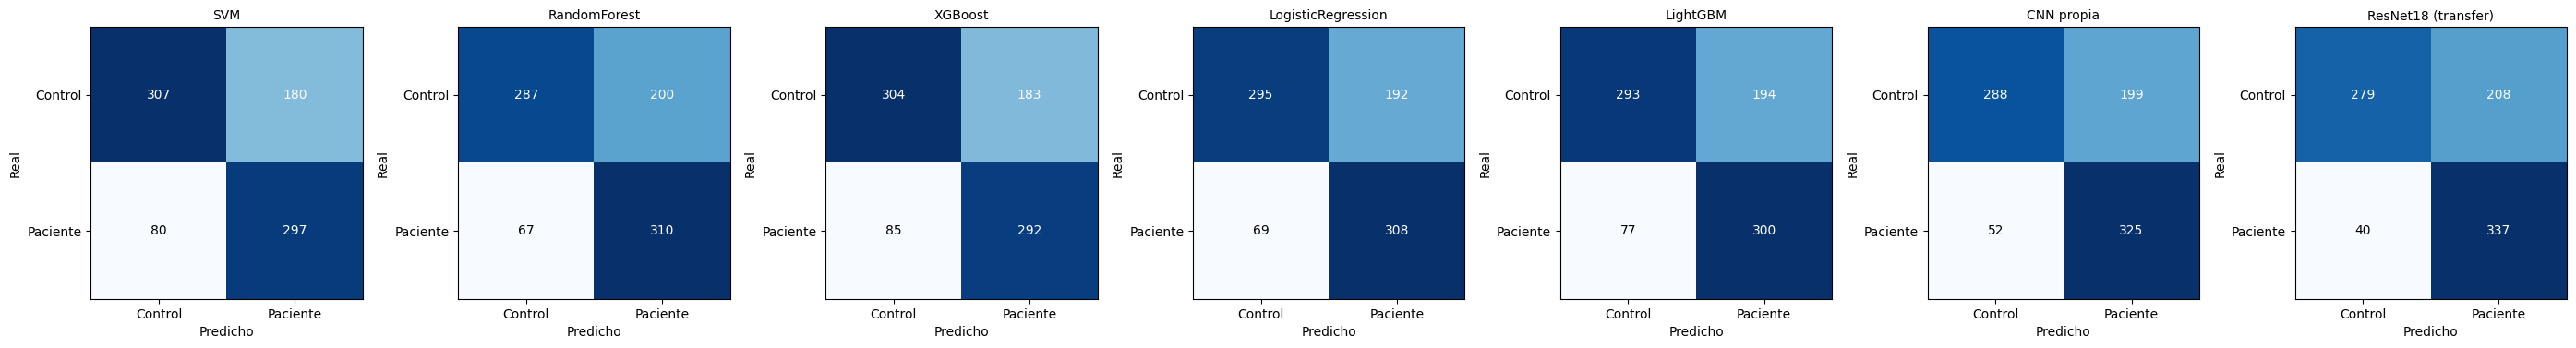

In [148]:
# =====================================================================
# 3. MATRICES DE CONFUSION DE TODOS LOS MODELOS
# =====================================================================
n_models = len(final_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, metrics) in zip(axes, final_results.items()):
    cm = np.array(metrics['confusion_matrix'])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Control', 'Paciente'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Control', 'Paciente'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('matrices_confusion_finales.pdf', dpi=300)
print("[OK] Matrices de confusion exportadas a 'matrices_confusion_finales.pdf'")

## Conclusiones

*(completar después de ver los resultados de la Fase 5: qué enfoque ganó — características tsfresh + ML clásico vs. imágenes tiempo-frecuencia + deep learning —, con qué métrica y margen, y si responde a la pregunta del objetivo del proyecto.)*

Esperar a los resultados, interpretar, ablation y discusión previamente :D